---

VIX calibration

---

# Imports

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
from rbergomi import RoughBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
import pandas as pd
import calibration

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)
COLORS = ["blue", "green", "red", "orange"]
SEED = 1234

# 22 Nov 2017

In [68]:
# load market data
df = pd.read_csv("data/vix_smile_2017.csv", sep=";")
df = df.iloc[0:9]
tab_strike = 1e-2 * df.iloc[0][4:-2].to_numpy().astype(float)
tab_mat = np.arange(1, 9) / 12
tab_fut = 1e-2 * df["F"][1:].to_numpy().astype(float)
tab_impvol = np.zeros((8, 16))
for i in range(1, 9):
    tab_impvol[i - 1, :] = np.array(df.iloc[i][4:-2]) / 100

In [69]:
tab_fut

array([0.1148, 0.1288, 0.1383, 0.1458, 0.1518, 0.1568, 0.1613, 0.167 ])

In [70]:
H = 0.1

list_x0 = np.array(
    [
        np.log(0.014483720994143206),
        np.log(0.0213),
        np.log(0.02629),
        np.log(0.02927),
    ]
)
list_eta1 = np.array([1.89695265, 1.85768486, 1.746, 1.40721303]) / np.sqrt(2 * H)
list_eta2 = np.array([0.19704152, 0.15271809, 0.167, 0.12376835]) / np.sqrt(2 * H)
list_lbd = np.array([0.32418895, 0.49170964, 0.55, 0.6499])

In [130]:
EPS = 1e-3
N_QUAD = 40
ORDER = 0

impvol_approx = {}
fut_approx = {}


for i in range(len(list_x0)):
    params = {
        "s0": 1.0,
        "xi0": lambda u: np.ones_like(u) * np.exp(list_x0[i]),
        "rho": -0.7,
        "H": H,
        "eta": list_eta1[i],
    }
    rbergomi = RoughBergomi(**params)

    lbd = list_lbd[i]
    eta_2 = list_eta2[i]
    T = tab_mat[i]
    fut_approx[T] = rbergomi.price_vix_approx_mixed(
        T=T,
        K=0.0,
        lbd=lbd,
        eta_2=eta_2,
        order=ORDER,
        opt_payoff="fut",
        eps=EPS,
        n_quad=N_QUAD,
    )
    k = np.log(tab_strike / fut_approx[T])

    impvol_approx[T] = rbergomi.implied_vol_vix_approx_mixed(
        lbd=lbd,
        eta_2=eta_2,
        k=k,
        T=T,
        order=ORDER,
        eps=EPS,
        n_quad=N_QUAD,
    )

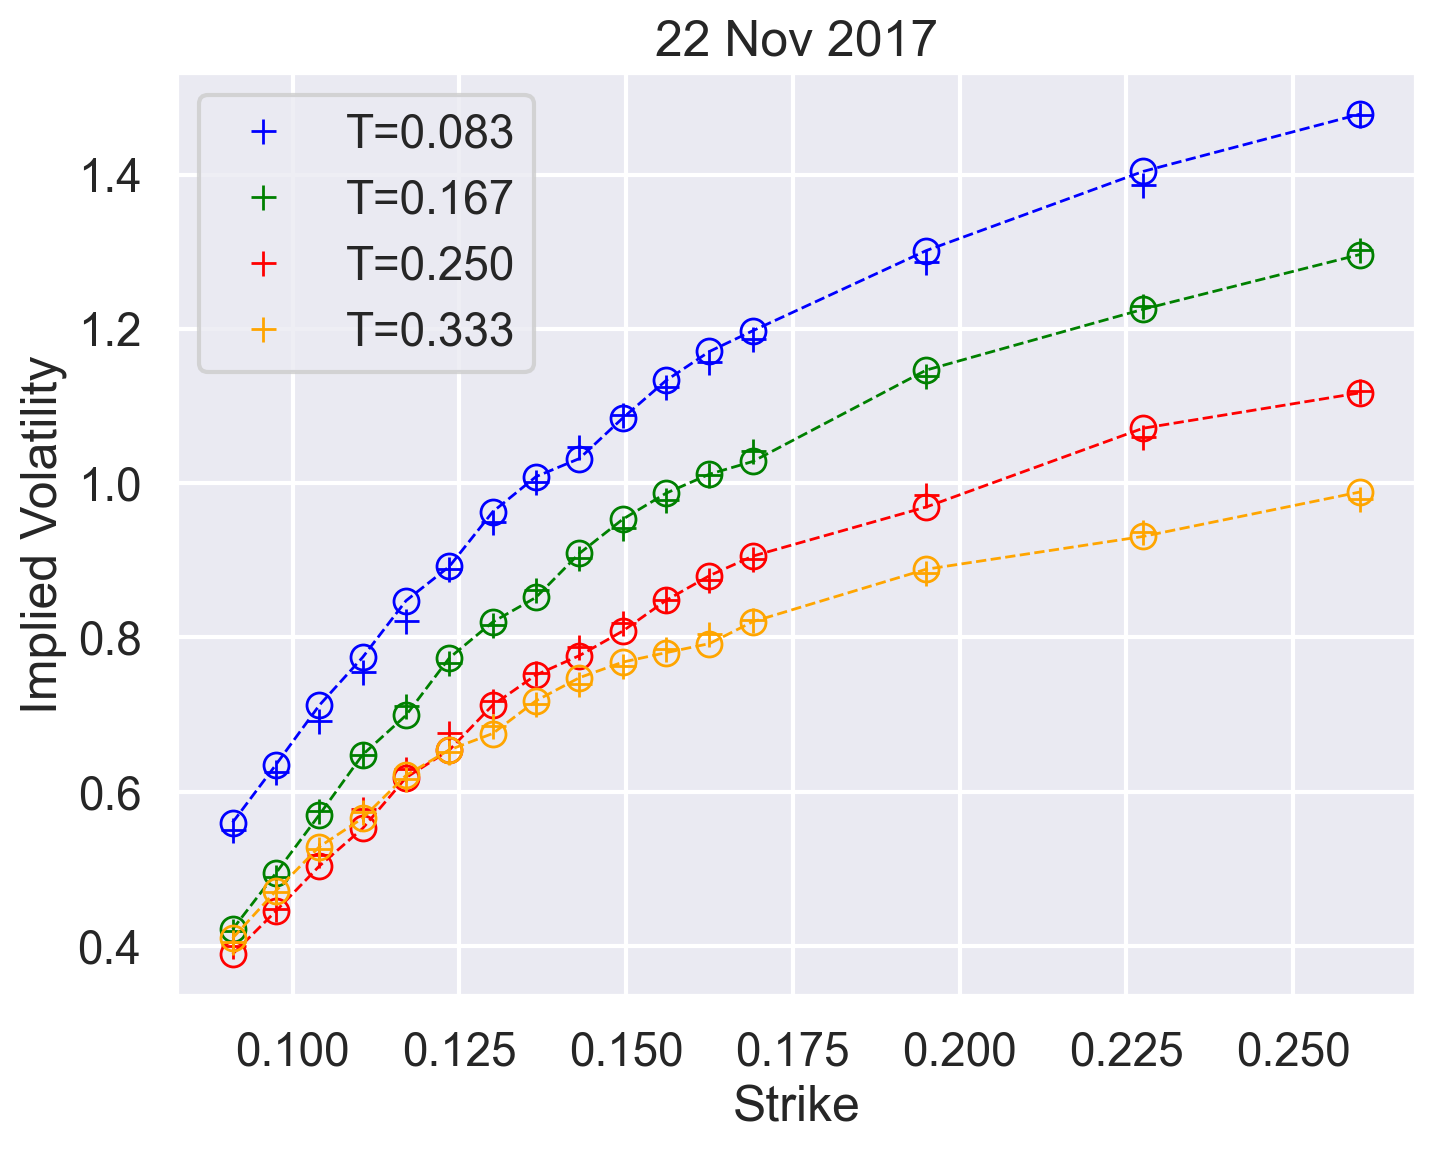

In [131]:
# plot vix smiles
fig, ax = plt.subplots()
for i in range(4):
    ax.plot(
        tab_strike,
        tab_impvol[i, :],
        "+",
        color=COLORS[i],
        label=f"T={tab_mat[i]:.3f}",
    )
    ax.plot(
        tab_strike,
        impvol_approx[tab_mat[i]],
        "--o",
        color=COLORS[i],
        fillstyle="none",
        linewidth=1.0,
    )
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.set_title("22 Nov 2017")
ax.legend()
plt.show()

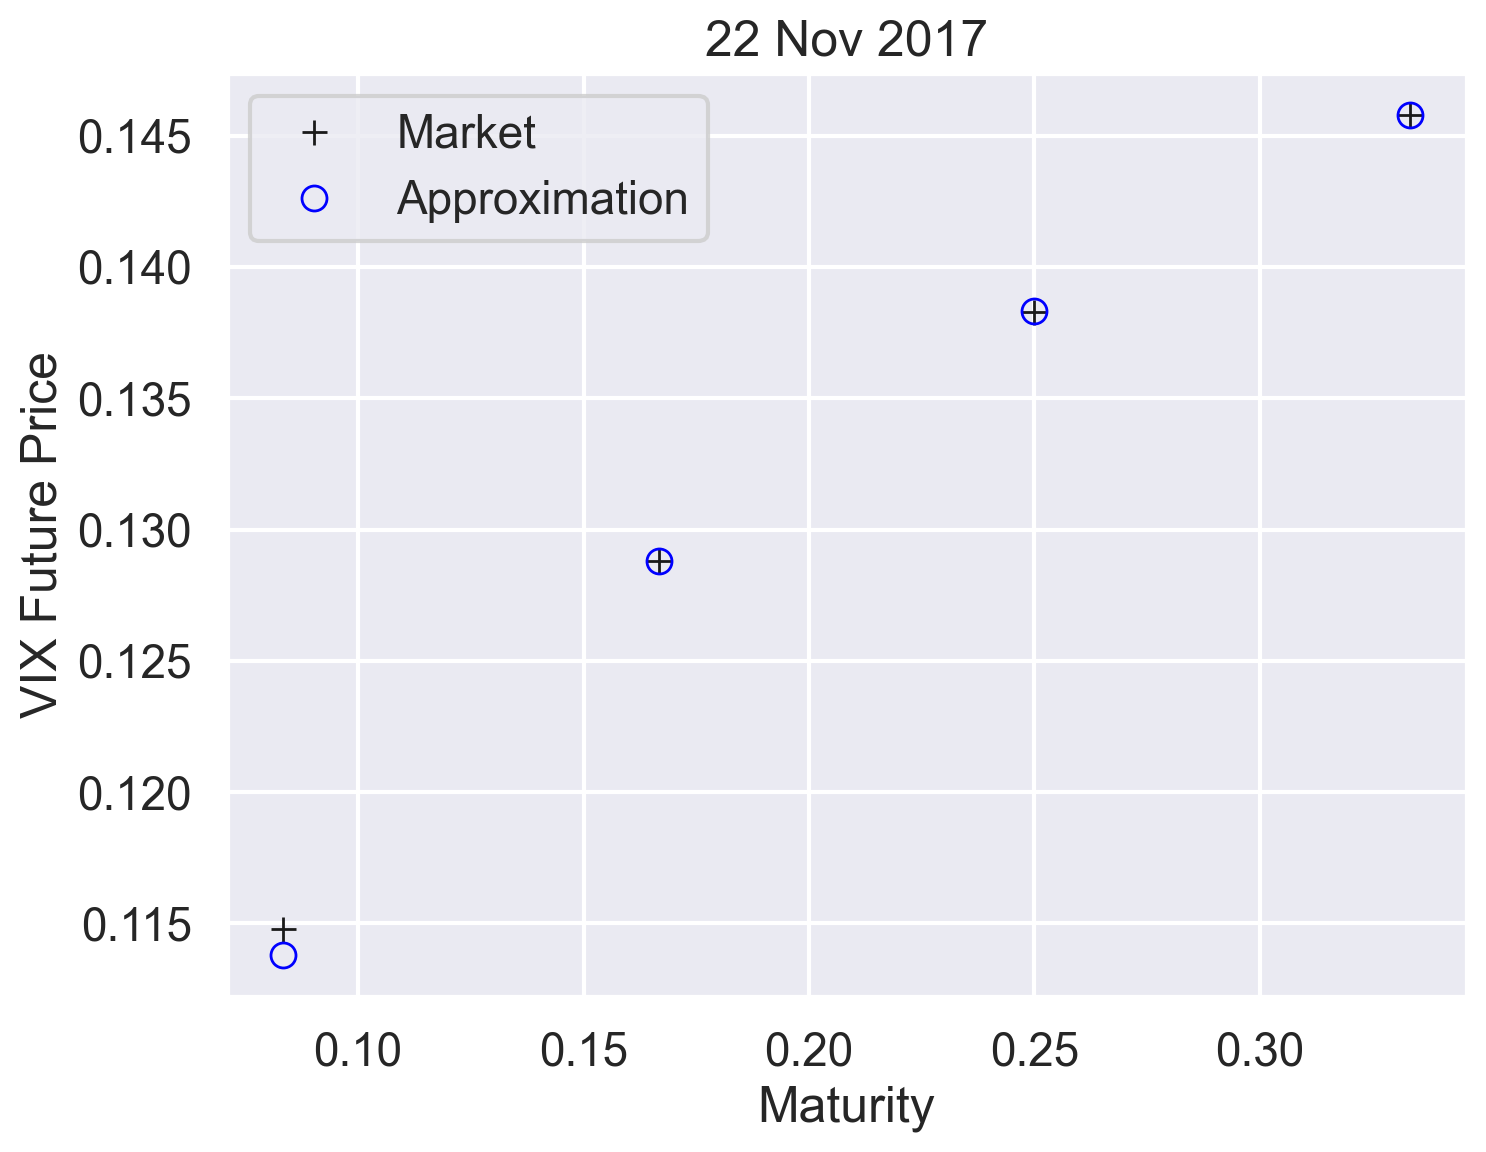

In [132]:
fig, ax = plt.subplots()
ax.plot(
    tab_mat[:4],
    tab_fut[:4],
    "+",
    color="k",
    label="Market",
)
ax.plot(
    tab_mat[:4],
    [fut_approx[T] for T in tab_mat[:4]],
    "o",
    color=COLORS[0],
    fillstyle="none",
    linewidth=1.0,
    label="Approximation",
)
ax.set_xlabel("Maturity")
ax.set_ylabel("VIX Future Price")
ax.set_title("22 Nov 2017")
ax.legend()
plt.show()

## Calibration

In [ ]:
# TODO: redo calibration. assume xi0 piecewise constant.
# be careful with overlaps of maturities.

# 2023-02-15

## Per maturity

In [15]:
# how to handle xi0 piecewise constant and the fact that maturities overlap?
# try the full smile with just one set of parameters.

In [17]:
df_spx = pd.read_csv("data/spx_implied_vol_20230215.csv", index_col=0).dropna()
df_vix = pd.read_csv("data/vix_implied_vol_20230215.csv", index_col=0).dropna()
df_spx["Texp_days"] = (365.25 * df_spx["Texp"]).round().astype(int)
df_vix["Texp_days"] = (365.25 * df_vix["Texp"]).round().astype(int)
df_vix["Mid"] = (df_vix["Ask"] + df_vix["Bid"]) / 2

In [18]:
mats_days = df_vix["Texp_days"].unique()
print(mats_days)

[  7  14  20  28  35  63  91 126 154 182 217 245]


In [19]:
mats_days + 30

array([ 37,  44,  50,  58,  65,  93, 121, 156, 184, 212, 247, 275])

In [20]:
np.unique(np.concatenate((mats_days, mats_days + 30)))

array([  7,  14,  20,  28,  35,  37,  44,  50,  58,  63,  65,  91,  93,
       121, 126, 154, 156, 182, 184, 212, 217, 245, 247, 275])

In [21]:
# # get xi0
# res_vs = var_swap_robust(ivol_data=df_spx)
# w_in = res_vs["vs_mid"] * res_vs["expiries"]
# xi0_smooth = xi_curve_smooth(res_vs["expiries"], w_in, eps=0.03)["xi_curve"]

In [22]:
# Extract unique maturities
vix_mats = df_vix["Texp"].unique()

In [23]:
# Filter the DataFrame for the first maturity
T = vix_mats[0]
df0 = df_vix[df_vix["Texp"] == T]

Ks = 1e-2 * df0["Strike"].to_numpy()
F = 1e-2 * df0["Fwd"].to_numpy()[0]
ks = np.log(Ks / F)
impvols = df0["Mid"].to_numpy()
weights = 1 / (df0["Ask"] - df0["Bid"]).to_numpy()

In [24]:
print(Ks)

[0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3
 0.31 0.32 0.33 0.34 0.35 0.36 0.4 ]


In [25]:
print(F)

0.201951741855249


In [26]:
# define optimization parameters

ORDER = 3
EPS = 1e-3
N_QUAD = 50

# xi0, H, eta_1, eta_2, lbd
x0_7d = np.array([0.04143876, 0.09227086, 6.18148555, 0.43356562, 0.12460595])
x0_35d = np.array([0.0454901, 0.13472347, 5.27801765, 0.58595415, 0.23542095])
x0_63d = np.array([0.0541161, 0.10168213, 4.79678822, 0.65320876, 0.32825003])

In [27]:
optim = calibration.optimize_calibration(
    x0=x0_7d,
    K=Ks,
    F=F,
    impvols=impvols,
    T=T,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    # weights=weights,
)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.6937e-02                                    5.88e-01    
       1              2         6.4729e-02      2.21e-03       2.04e-02       1.80e+01    
       2              3         6.1301e-02      3.43e-03       3.77e-02       3.32e+01    
       3              4         5.2789e-02      8.51e-03       4.02e-02       7.48e+01    
       4              5         4.1700e-02      1.11e-02       3.78e-02       3.37e-02    
       5              9         4.1684e-02      1.63e-05       1.46e-04       1.82e+00    
       6             16         4.1684e-02      2.61e-08       1.95e-07       7.03e-01    
       7             18         4.1684e-02      0.00e+00       0.00e+00       7.03e-01    
`xtol` termination condition is satisfied.
Function evaluations 18, initial cost 6.6937e-02, final cost 4.1684e-02, first-order optimality 7.03e-01.


In [28]:
print("Optimized parameters:")
optim.x

Optimized parameters:


array([0.04140415, 0.08478286, 6.05986503, 0.47797952, 0.12245342])

In [29]:
x_optim = optim.x

F_approx, impvols_approx = calibration.fun(
    x_optim,
    K=Ks,
    F=F,
    impvols=impvols,
    T=T,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    return_error=False,
)

In [30]:
x_optim

array([0.04140415, 0.08478286, 6.05986503, 0.47797952, 0.12245342])

In [31]:
0.308644 / np.sqrt(2 * 0.1)

np.float64(0.690148964847445)

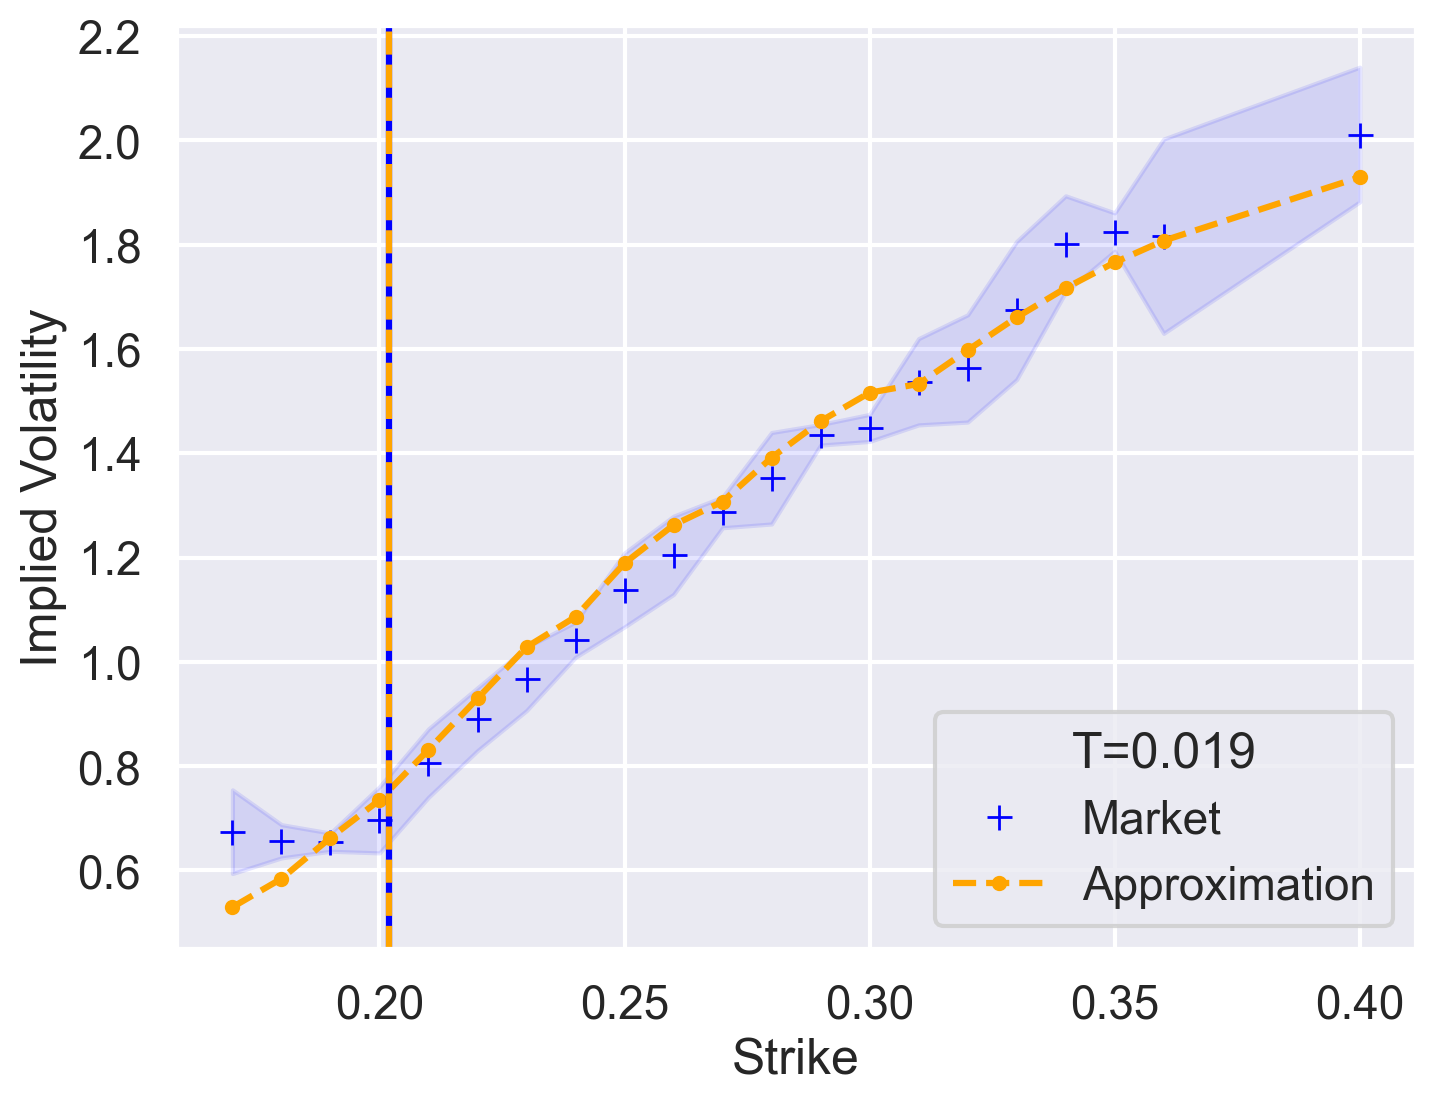

In [32]:
fig, ax = plt.subplots()
ax.plot(Ks, impvols, "+", color="blue", label="Market")
ax.fill_between(Ks, df0["Bid"], df0["Ask"], color="blue", alpha=0.1)
ax.plot(
    Ks,
    impvols_approx,
    ".--",
    color="orange",
    label="Approximation",
)
ax.axvline(F, color="blue", linestyle="-")
ax.axvline(F_approx, color="orange", linestyle="--")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.legend(title=f"T={T:.3f}")
plt.show()

In [73]:
# TODO: try to calibrate all smiles at once

## Several maturities at once

We assume that 

$$
    \xi_0(u) = \beta_0 + \beta_1 e^{-u/\tau_1} + \beta_2 (u/\tau_2) e^{-u/\tau_2}
$$

In [3]:
N_QUAD = 50
ORDER = 3
EPS = 1e-3

In [4]:
df_vix = pd.read_csv("data/vix_implied_vol_20230215.csv", index_col=0).dropna()
df_vix["Texp_days"] = (365.25 * df_vix["Texp"]).round().astype(int)
df_vix["Mid"] = (df_vix["Ask"] + df_vix["Bid"]) / 2
mats_days = df_vix["Texp_days"].unique()
voldata = {}
for day in mats_days:
    df_temp = df_vix[df_vix["Texp_days"] == day]
    voldata[day] = {
        "K": 1e-2 * df_temp["Strike"].to_numpy(),
        "F": 1e-2 * df_temp["Fwd"].to_numpy()[0],
        "Mid": df_temp["Mid"].to_numpy(),
        "Ask": df_temp["Ask"].to_numpy(),
        "Bid": df_temp["Bid"].to_numpy(),
        "weights": 1 / (df_temp["Ask"] - df_temp["Bid"]).to_numpy(),
    }
    voldata[day]["k"] = np.log(voldata[day]["K"] / voldata[day]["F"])

In [5]:
print("List of VIX maturities (days):")
mats_days

List of VIX maturities (days):


array([  7,  14,  20,  28,  35,  63,  91, 126, 154, 182, 217, 245])

In [33]:
calib_days = [7, 14, 20, 28, 35, 63, 91]

In [34]:
# initial guess
x0 = np.array(
    [
        0.04177604,
        -0.0178205,
        0.05688351,
        5.30435286,
        0.10086534,
        0.18471947,
        4.89784587,
        0.56020433,
        0.17334996,
    ]
)

res_calib = calibration.optimize_calibration_all(
    x0=x0,
    voldata=voldata,
    days=calib_days,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    weights=False,
)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.6654e+00                                    1.20e+03    
       1              2         3.6985e+00      1.97e+00       1.53e-01       1.45e+02    
       2              3         3.4005e+00      2.98e-01       2.92e-01       7.60e+01    
       3              6         3.2049e+00      1.96e-01       3.21e-01       2.43e+02    
       4              7         2.7358e+00      4.69e-01       1.11e-01       9.20e+01    
       5             10         2.7250e+00      1.08e-02       2.07e-02       1.63e+02    
       6             11         2.6839e+00      4.11e-02       2.06e-02       1.38e+02    
       7             12         2.6492e+00      3.47e-02       1.60e-02       2.32e+02    
       8             13         2.5586e+00      9.07e-02       4.08e-02       9.96e+01    
       9             14         2.5261e+00      3.25e-02       7.85e-02       8.00e+00    

In [35]:
# x = b0, b1, b2, tau1, tau2, H, eta_1, eta_2, lbd

x_optim = res_calib.x

list_Fs_approx, list_impvols_approx = calibration.fun_all(
    x=x_optim,
    voldata=voldata,
    days=calib_days,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    return_error=False,
)

In [36]:
x_optim

array([ 0.0658651 , -0.02762876,  0.07485283,  4.97406961,  1.23254024,
        0.23786311,  4.80171638,  0.62049286,  0.19629762])

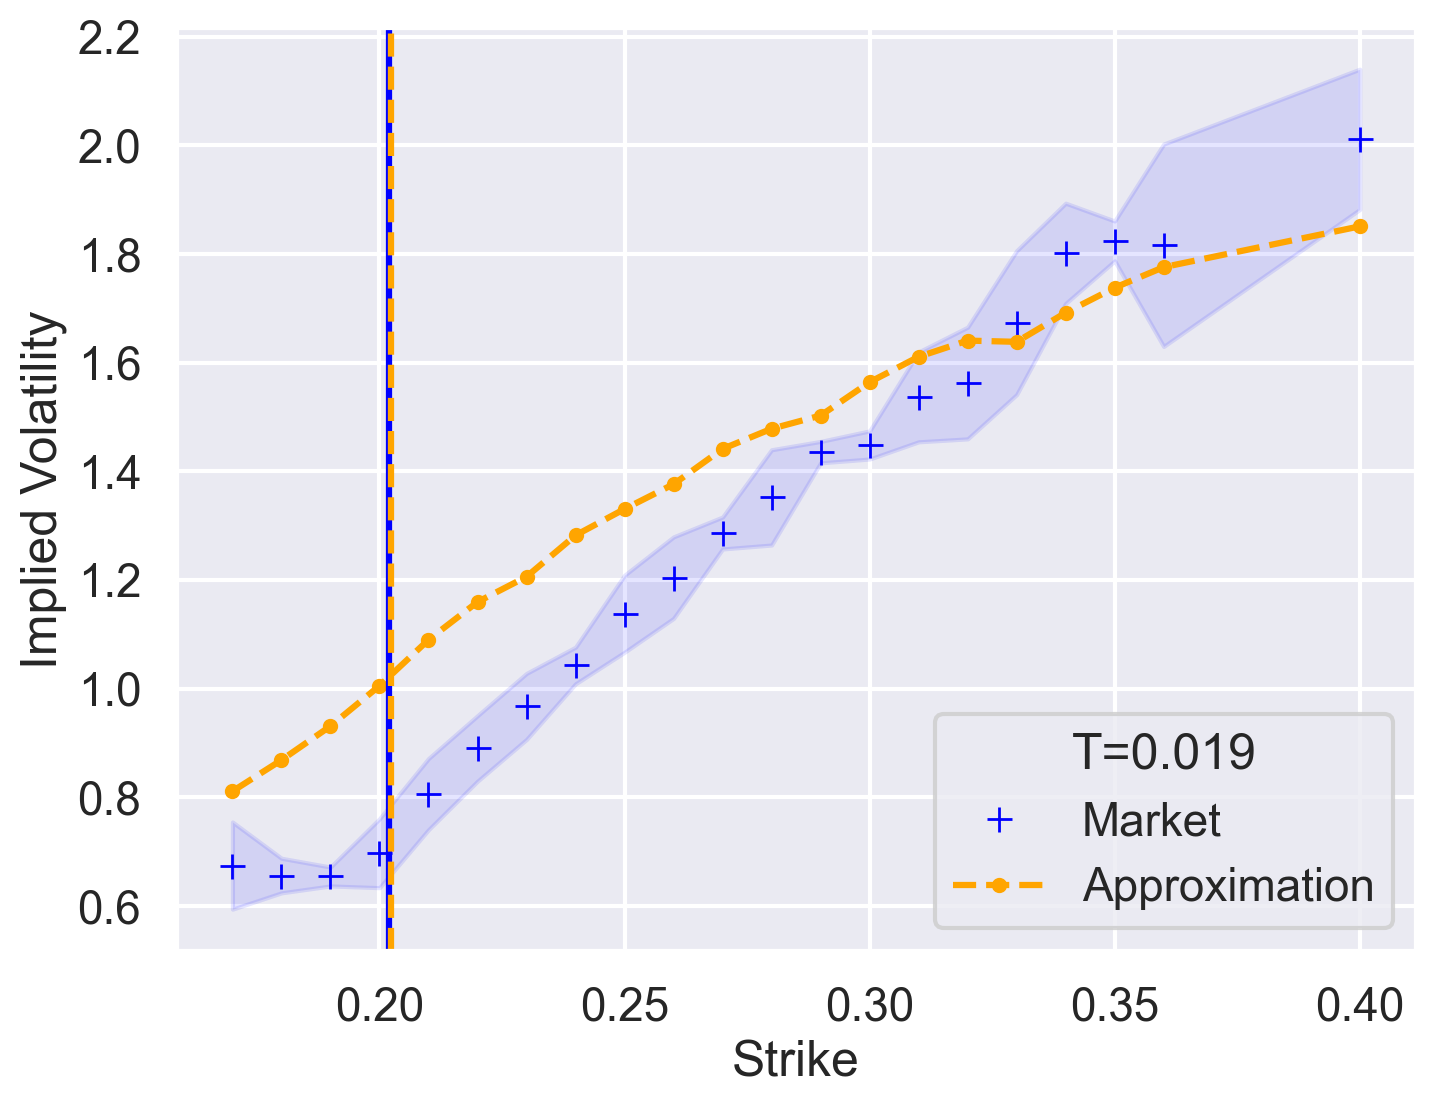

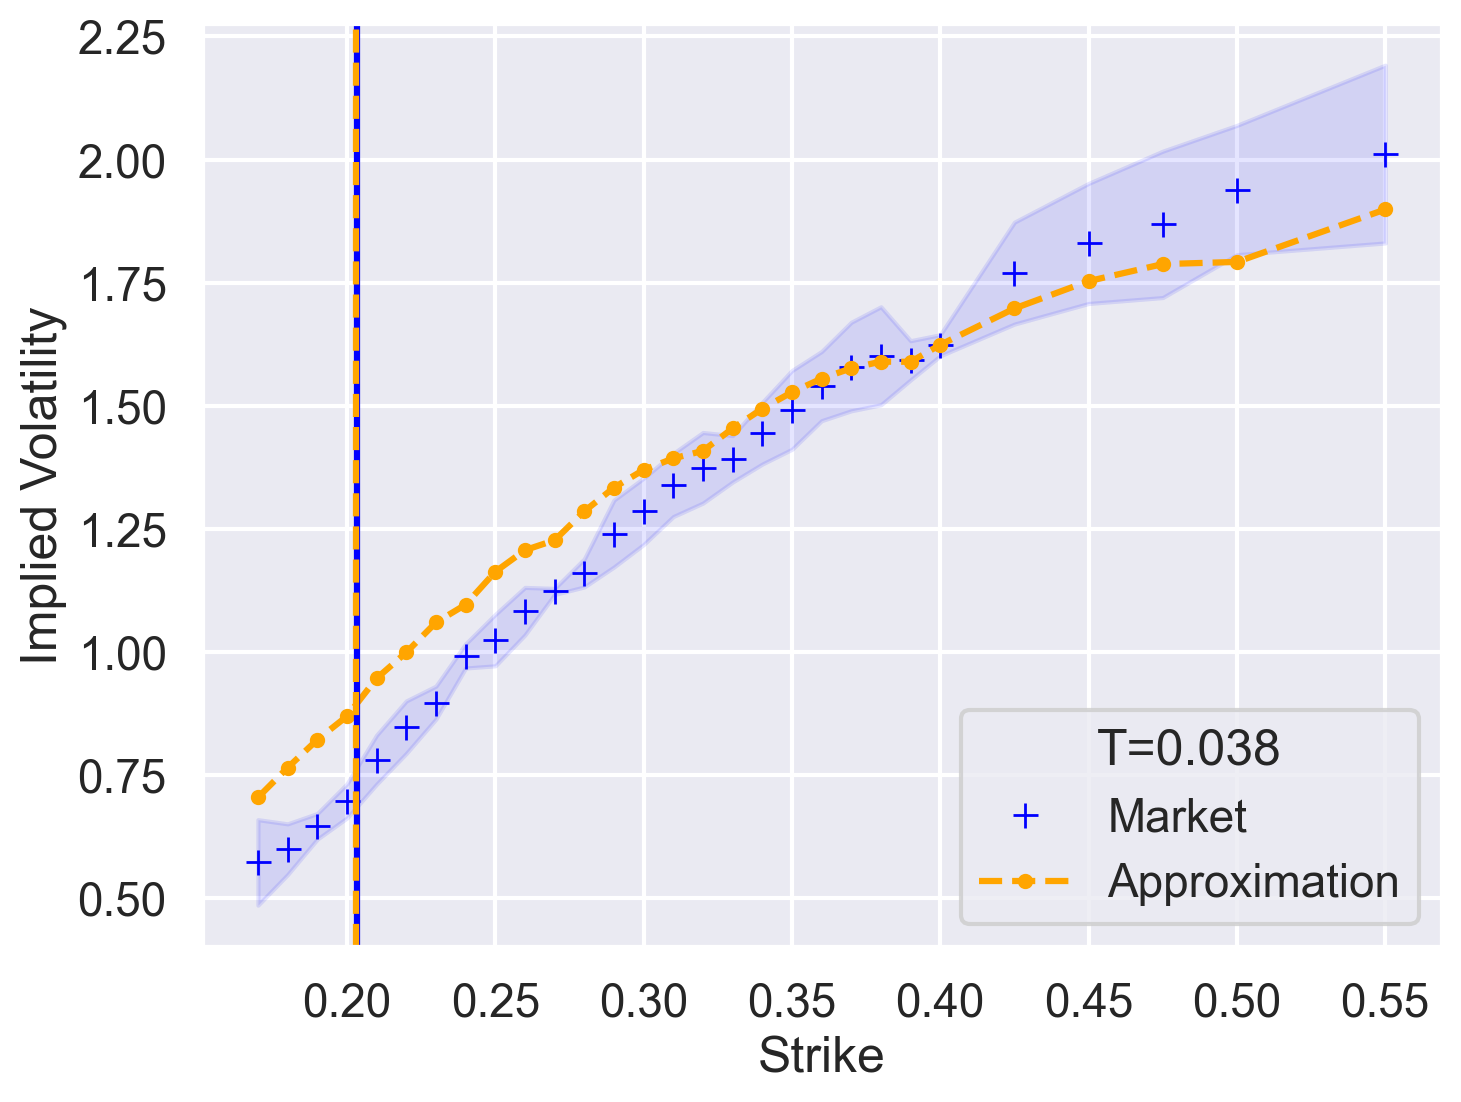

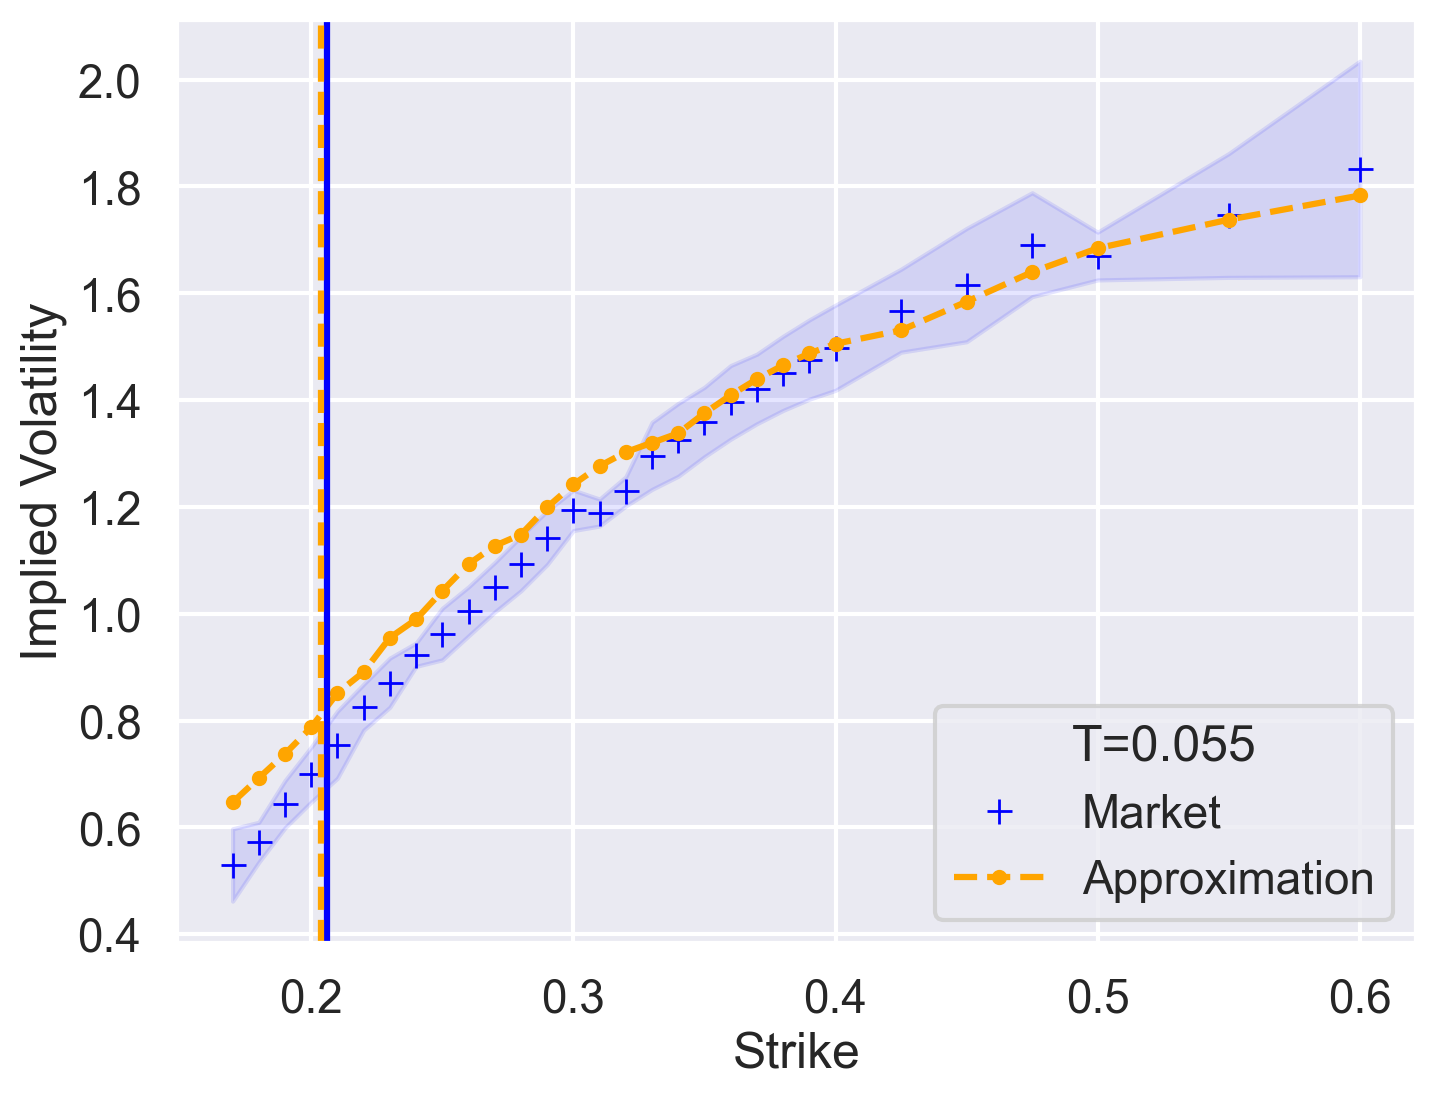

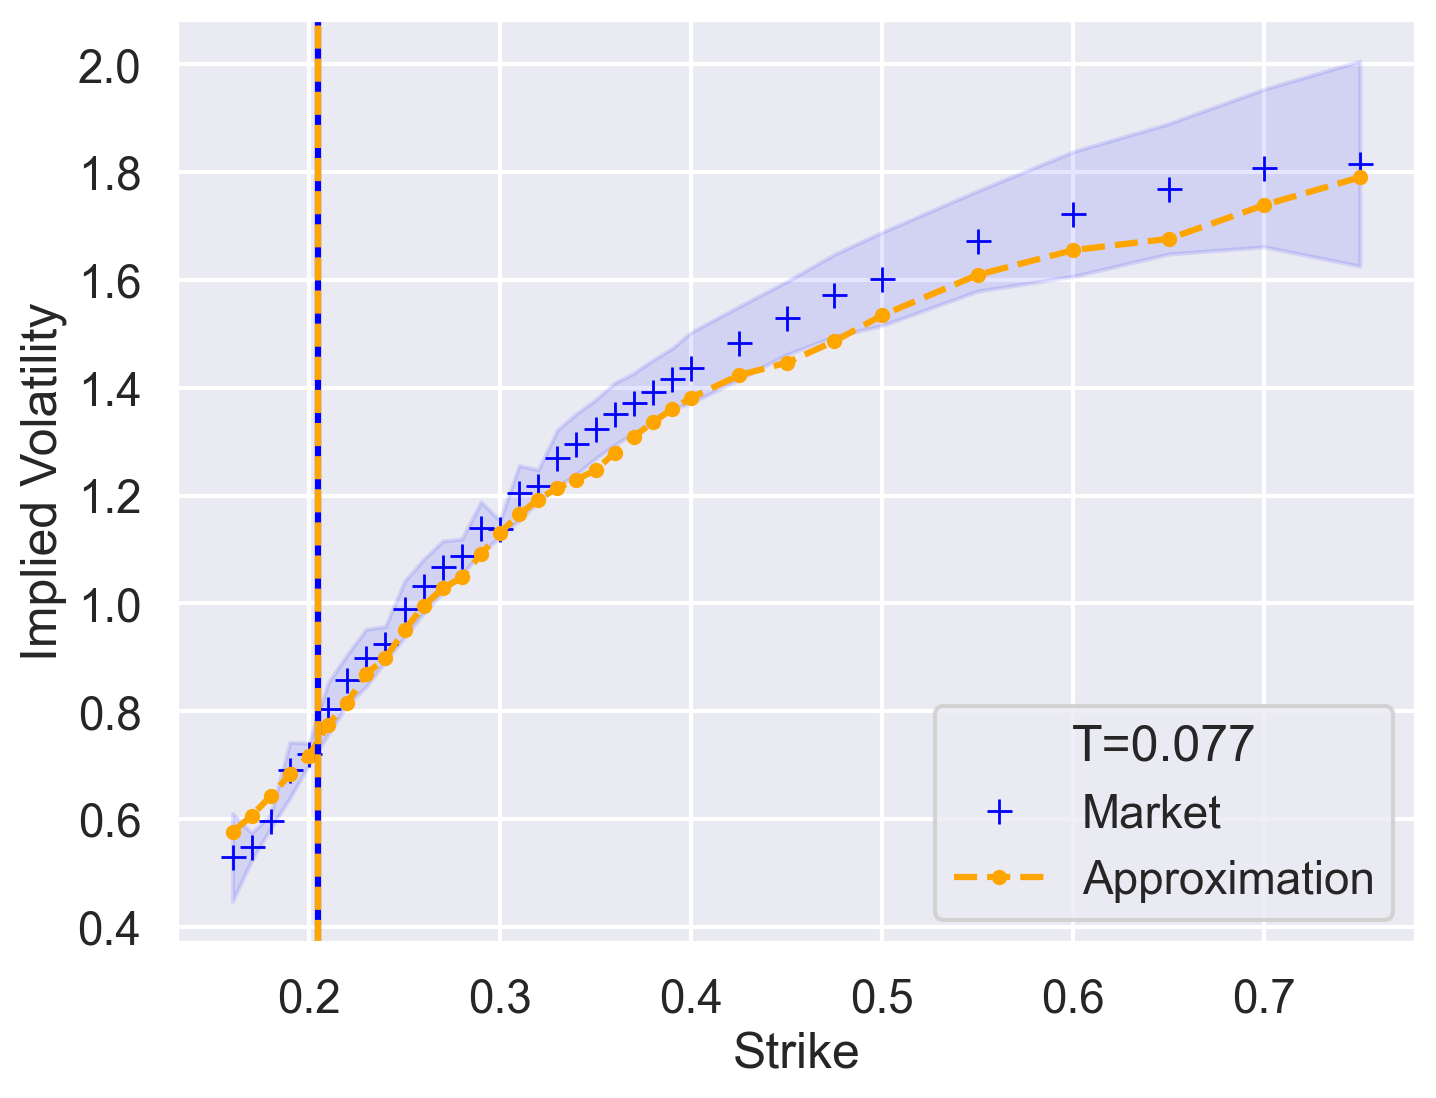

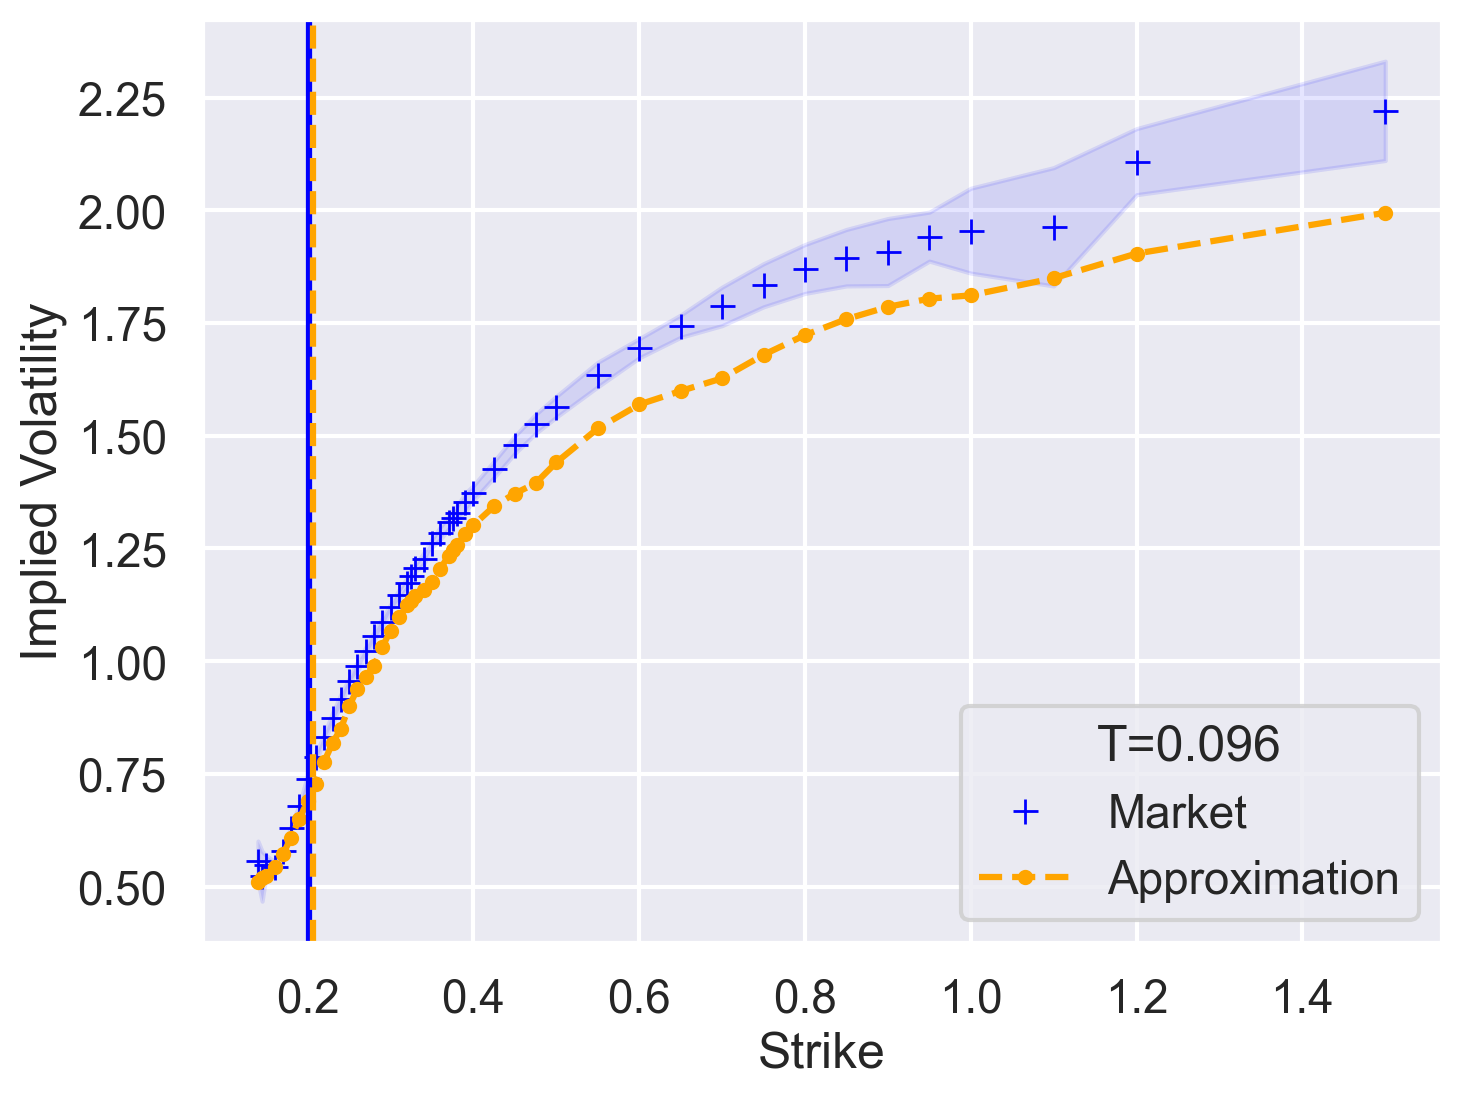

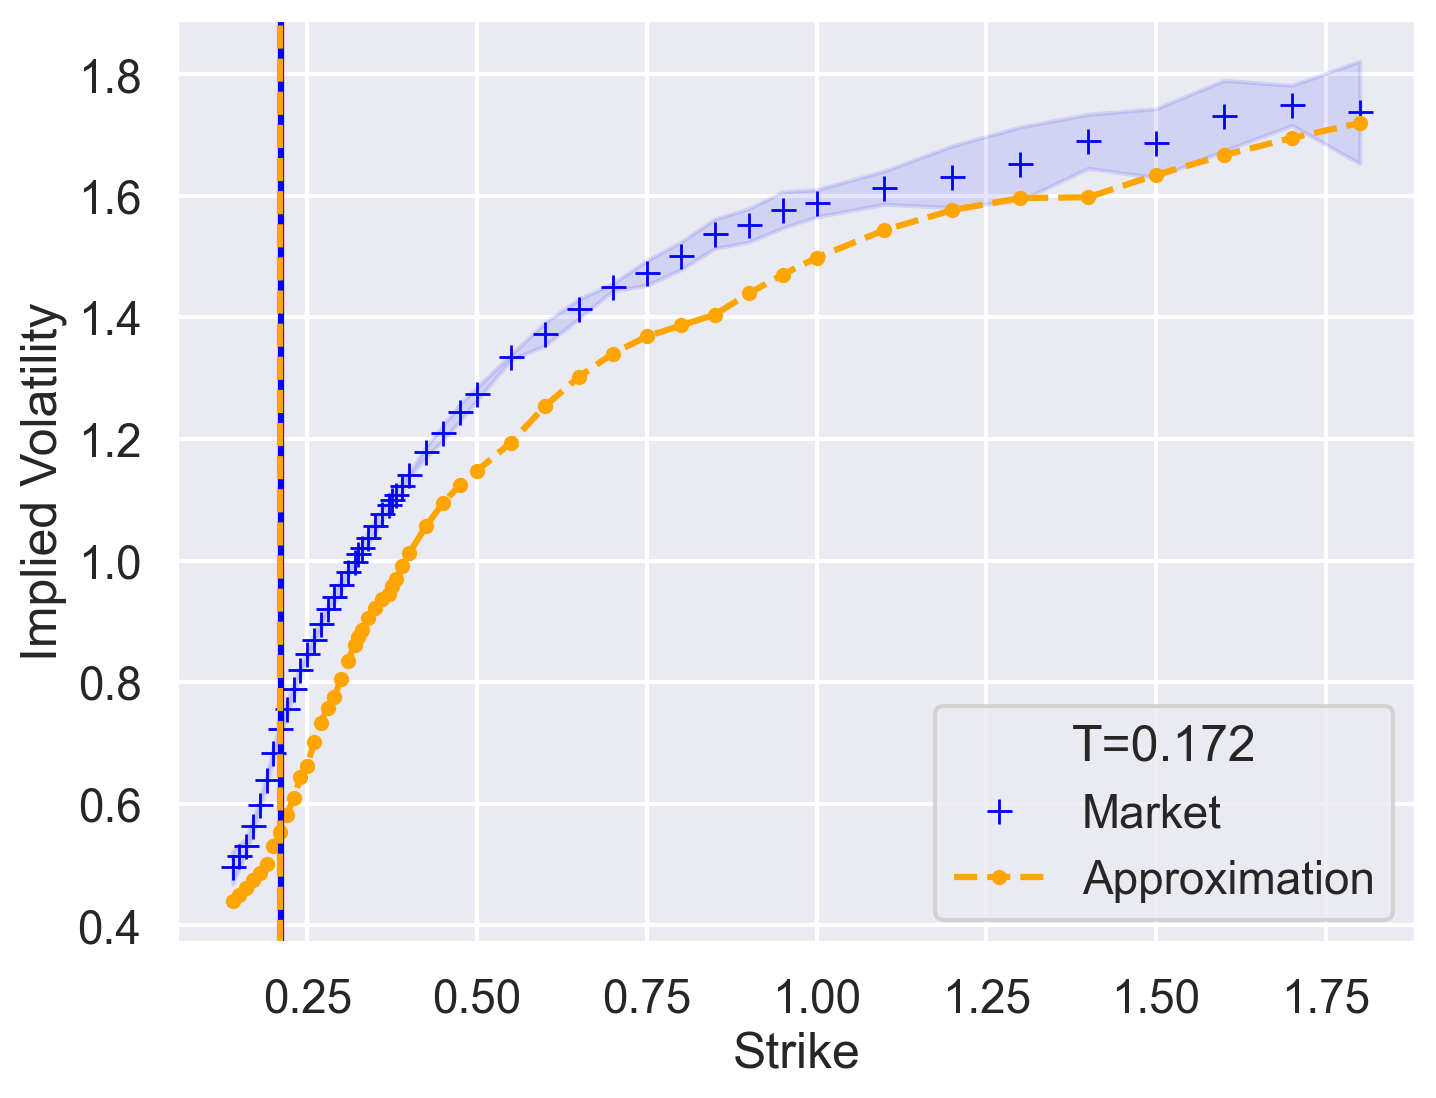

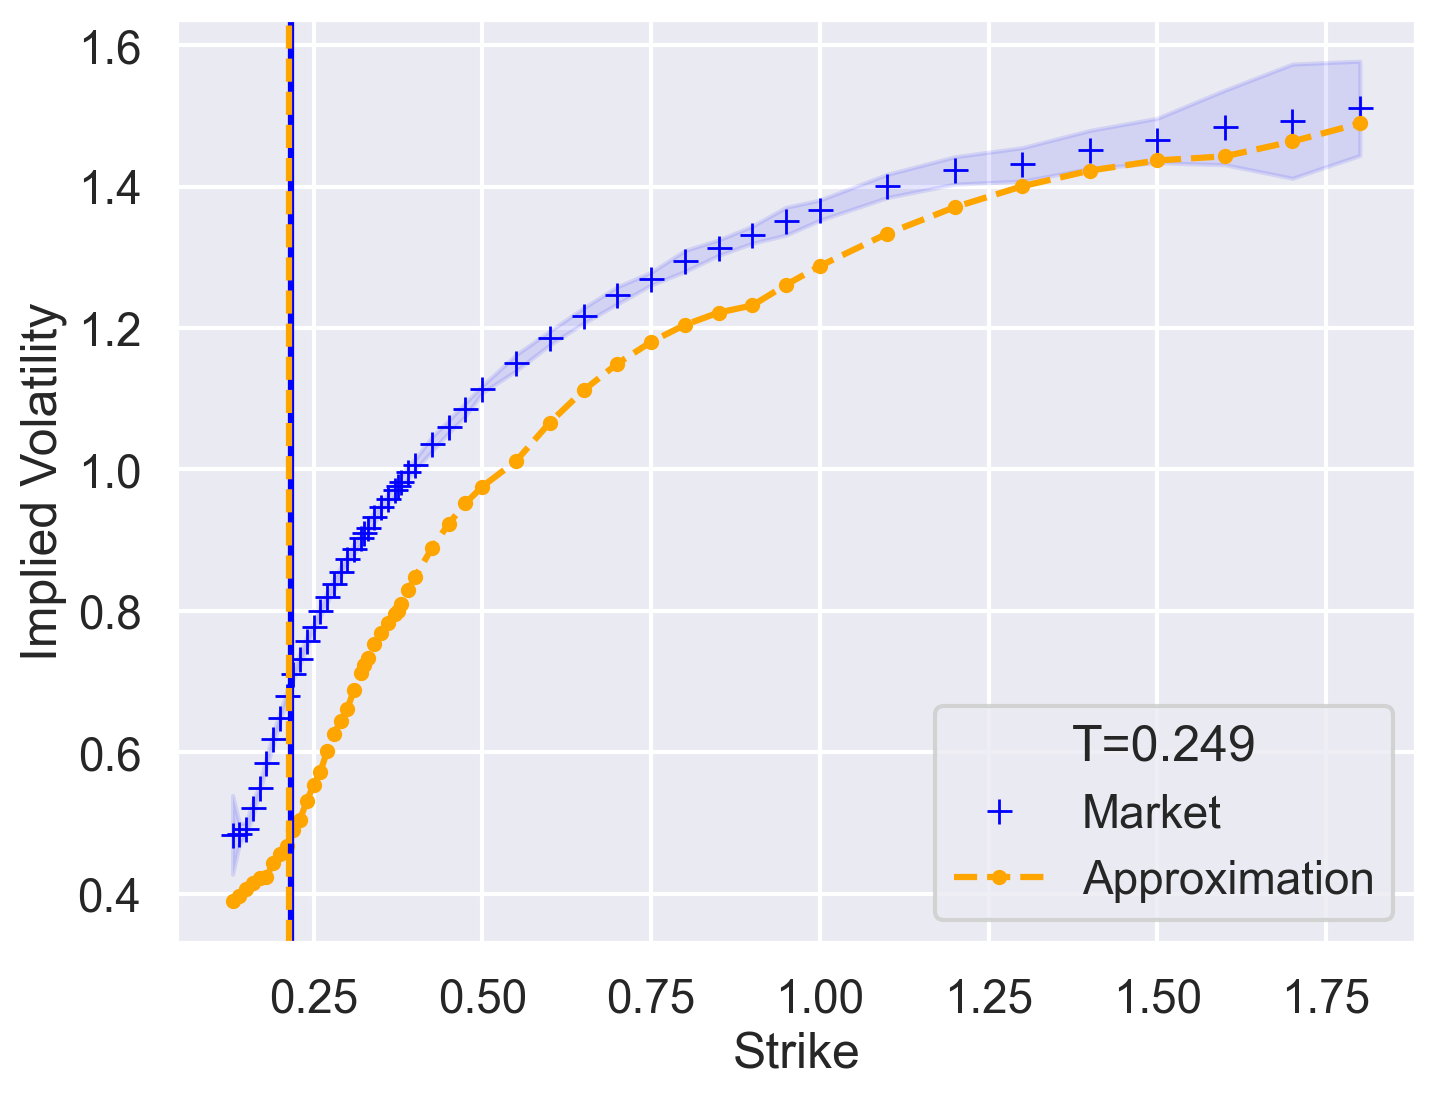

In [37]:
for i, day in enumerate(calib_days):
    Ks_day = voldata[day]["K"]
    F_day = voldata[day]["F"]
    F_approx_day = list_Fs_approx[i]
    impvols_day = voldata[day]["Mid"]
    impvols_approx_day = list_impvols_approx[i]
    T = day / 365.25

    fig, ax = plt.subplots()
    ax.plot(Ks_day, impvols_day, "+", color="blue", label="Market")
    ax.fill_between(
        Ks_day, voldata[day]["Bid"], voldata[day]["Ask"], color="blue", alpha=0.1
    )
    ax.plot(
        Ks_day,
        impvols_approx_day,
        ".--",
        color="orange",
        label="Approximation",
    )
    ax.axvline(F_day, color="blue", linestyle="-")
    ax.axvline(F_approx_day, color="orange", linestyle="--")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Implied Volatility")
    ax.legend(title=f"T={T:.3f}")
    plt.show()